# **Практическая работа №10. Использование модели YOLOv12 для решение задач детекции и классификации**

## **Задание 1. Знакомство с новейшей версией модели YOLO**

- Ознакомьтесь с технической документацией по новейшей версии модели YOLOv12: https://docs.ultralytics.com/ru/models/yolo12/

- Рассмотрите пример обучения этой модели c использованием датасетов, созданных в Roboflow: https://blog.roboflow.com/train-yolov12-model/

### **Ответьте на вопрос: Какие принципиальные отличия появились в модели YOLOv12 относительно предыдущих версий?**

**ВАШ ОТВЕТ**

YOLO12 демонстрирует значительное повышение точности во всех масштабах модели по сравнению с предыдущими моделями YOLO , такими как YOLOv10 и YOLO11, при этом скорость работы несколько снижается по сравнению с самыми быстрыми предыдущими моделями. Например, YOLO12n достигает +2,1 % улучшения mAP по сравнению с YOLOv10n и +1,2 % по сравнению с YOLO11n на наборе данных COCO val2017. По сравнению с такими моделями, как RT-DETRYOLO12s предлагает улучшение на +1,5 % по mAP и значительное увеличение скорости на +42 %. Эти показатели подчеркивают сильный баланс между точностью и эффективностью YOLO12.

*Примечание:* для каждого последующего задания, в конечном итоге, необходимо сформировать обученную модель и задеплоить её на сервисе **RoboFlow**



## **Задание 2. Найдите готовый датасет для детекции объектов и обучите на нем модель YOLOv12:**

- Для удобства работы с датасетом и деплоя модели используйте сервис [RoboFlow](https://roboflow.com/)

In [2]:
import os
from google.colab import userdata

os.environ["ROBOFLOW_API_KEY"] = userdata.get("ROBOFLOW_API_KEY")

In [3]:
!nvidia-smi

Tue May  6 22:39:32 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   36C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [4]:
import os
HOME = os.getcwd()
print(HOME)

/content


In [5]:
!pip install -q git+https://github.com/sunsmarterjie/yolov12.git roboflow supervision flash-attn

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.0/6.0 MB 81.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.3/85.3 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 19.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 181.5/181.5 kB 13.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 93.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 51.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 55.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 55.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [6]:
from roboflow import download_dataset

dataset = download_dataset('https://universe.roboflow.com/roboflow-100/soccer-players-5fuqs/dataset/2', 'yolov12')

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to soccer-players-2 in yolov12:: 100%|██████████| 338/338 [00:00<00:00, 2009.87it/s]


In [7]:
!ls {dataset.location}

data.yaml  README.dataset.txt  README.roboflow.txt  test  train  valid


In [8]:
!sed -i '$d' {dataset.location}/data.yaml
!sed -i '$d' {dataset.location}/data.yaml
!sed -i '$d' {dataset.location}/data.yaml
!sed -i '$d' {dataset.location}/data.yaml
!echo -e "test: ../test/images\ntrain: ../train/images\nval: ../valid/images" >> {dataset.location}/data.yaml

In [9]:
!cat {dataset.location}/data.yaml

train: ../train/images
val: ../valid/images
test: ../test/images

nc: 3
names: ['football', 'player', 'referee']

roboflow:
  workspace: roboflow-100
test: ../test/images
train: ../train/images
val: ../valid/images


In [10]:
from ultralytics import YOLO

model = YOLO('yolov12s.yaml')

results = model.train(data=f'{dataset.location}/data.yaml', epochs=100)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/yolov12/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
FlashAttention is not available on this device. Using scaled_dot_product_attention instead.
New https://pypi.org/project/ultralytics/8.3.128 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.3.63 🚀 Python-3.11.12 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: task=detect, mode=train, model=yolov12s.yaml, data=/content/soccer-players-2/data.yaml, epochs=100, time=None, patience=100, batch=16, imgsz=640, save=True, save_period=-1, cache=False, device=None, workers=8, project=None, name=train, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False,

100%|██████████| 755k/755k [00:00<00:00, 81.7MB/s]


Overriding model.yaml nc=80 with nc=3

                   from  n    params  module                                       arguments                     
  0                  -1  1       928  ultralytics.nn.modules.conv.Conv             [3, 32, 3, 2]                 
  1                  -1  1      9344  ultralytics.nn.modules.conv.Conv             [32, 64, 3, 2, 1, 2]          
  2                  -1  1     26080  ultralytics.nn.modules.block.C3k2            [64, 128, 1, False, 0.25]     
  3                  -1  1     37120  ultralytics.nn.modules.conv.Conv             [128, 128, 3, 2, 1, 4]        
  4                  -1  1    103360  ultralytics.nn.modules.block.C3k2            [128, 256, 1, False, 0.25]    
  5                  -1  1    590336  ultralytics.nn.modules.conv.Conv             [256, 256, 3, 2]              
  6                  -1  2    677120  ultralytics.nn.modules.block.A2C2f           [256, 256, 2, True, 4]        
  7                  -1  1   1180672  ultralytics

100%|██████████| 5.26M/5.26M [00:00<00:00, 7.72MB/s]


AMP: checks passed ✅


...

    100/100      6.99G      1.363     0.6887      1.089         21        640: 100%|██████████| 8/8 [00:04<00:00,  1.95it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 2/2 [00:00<00:00,  6.73it/s]

                   all         33        407      0.852      0.759      0.801      0.434



100 epochs completed in 0.156 hours.
Optimizer stripped from runs/detect/train/weights/last.pt, 18.6MB
Optimizer stripped from runs/detect/train/weights/best.pt, 18.6MB

Validating runs/detect/train/weights/best.pt...
Ultralytics 8.3.63 🚀 Python-3.11.12 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
YOLOv12s summary (fused): 376 layers, 9,075,369 parameters, 0 gradients, 19.3 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 2/2 [00:00<00:00,  5.43it/s]


                   all         33        407      0.877      0.753      0.805      0.436
              football         28         28      0.913      0.374      0.513      0.142
                player         33        359      0.967      0.936      0.983      0.585
               referee         20         20      0.752       0.95       0.92       0.58
Speed: 0.1ms preprocess, 5.4ms inference, 0.0ms loss, 1.2ms postprocess per image
Results saved to runs/detect/train


In [12]:
import locale
locale.getpreferredencoding = lambda: "UTF-8"

!ls {HOME}/runs/detect/train/

args.yaml					   train_batch0.jpg
confusion_matrix_normalized.png			   train_batch1.jpg
confusion_matrix.png				   train_batch2.jpg
events.out.tfevents.1746571340.a06ffb3ef857.981.0  train_batch720.jpg
F1_curve.png					   train_batch721.jpg
labels_correlogram.jpg				   train_batch722.jpg
labels.jpg					   val_batch0_labels.jpg
P_curve.png					   val_batch0_pred.jpg
PR_curve.png					   val_batch1_labels.jpg
R_curve.png					   val_batch1_pred.jpg
results.csv					   weights
results.png


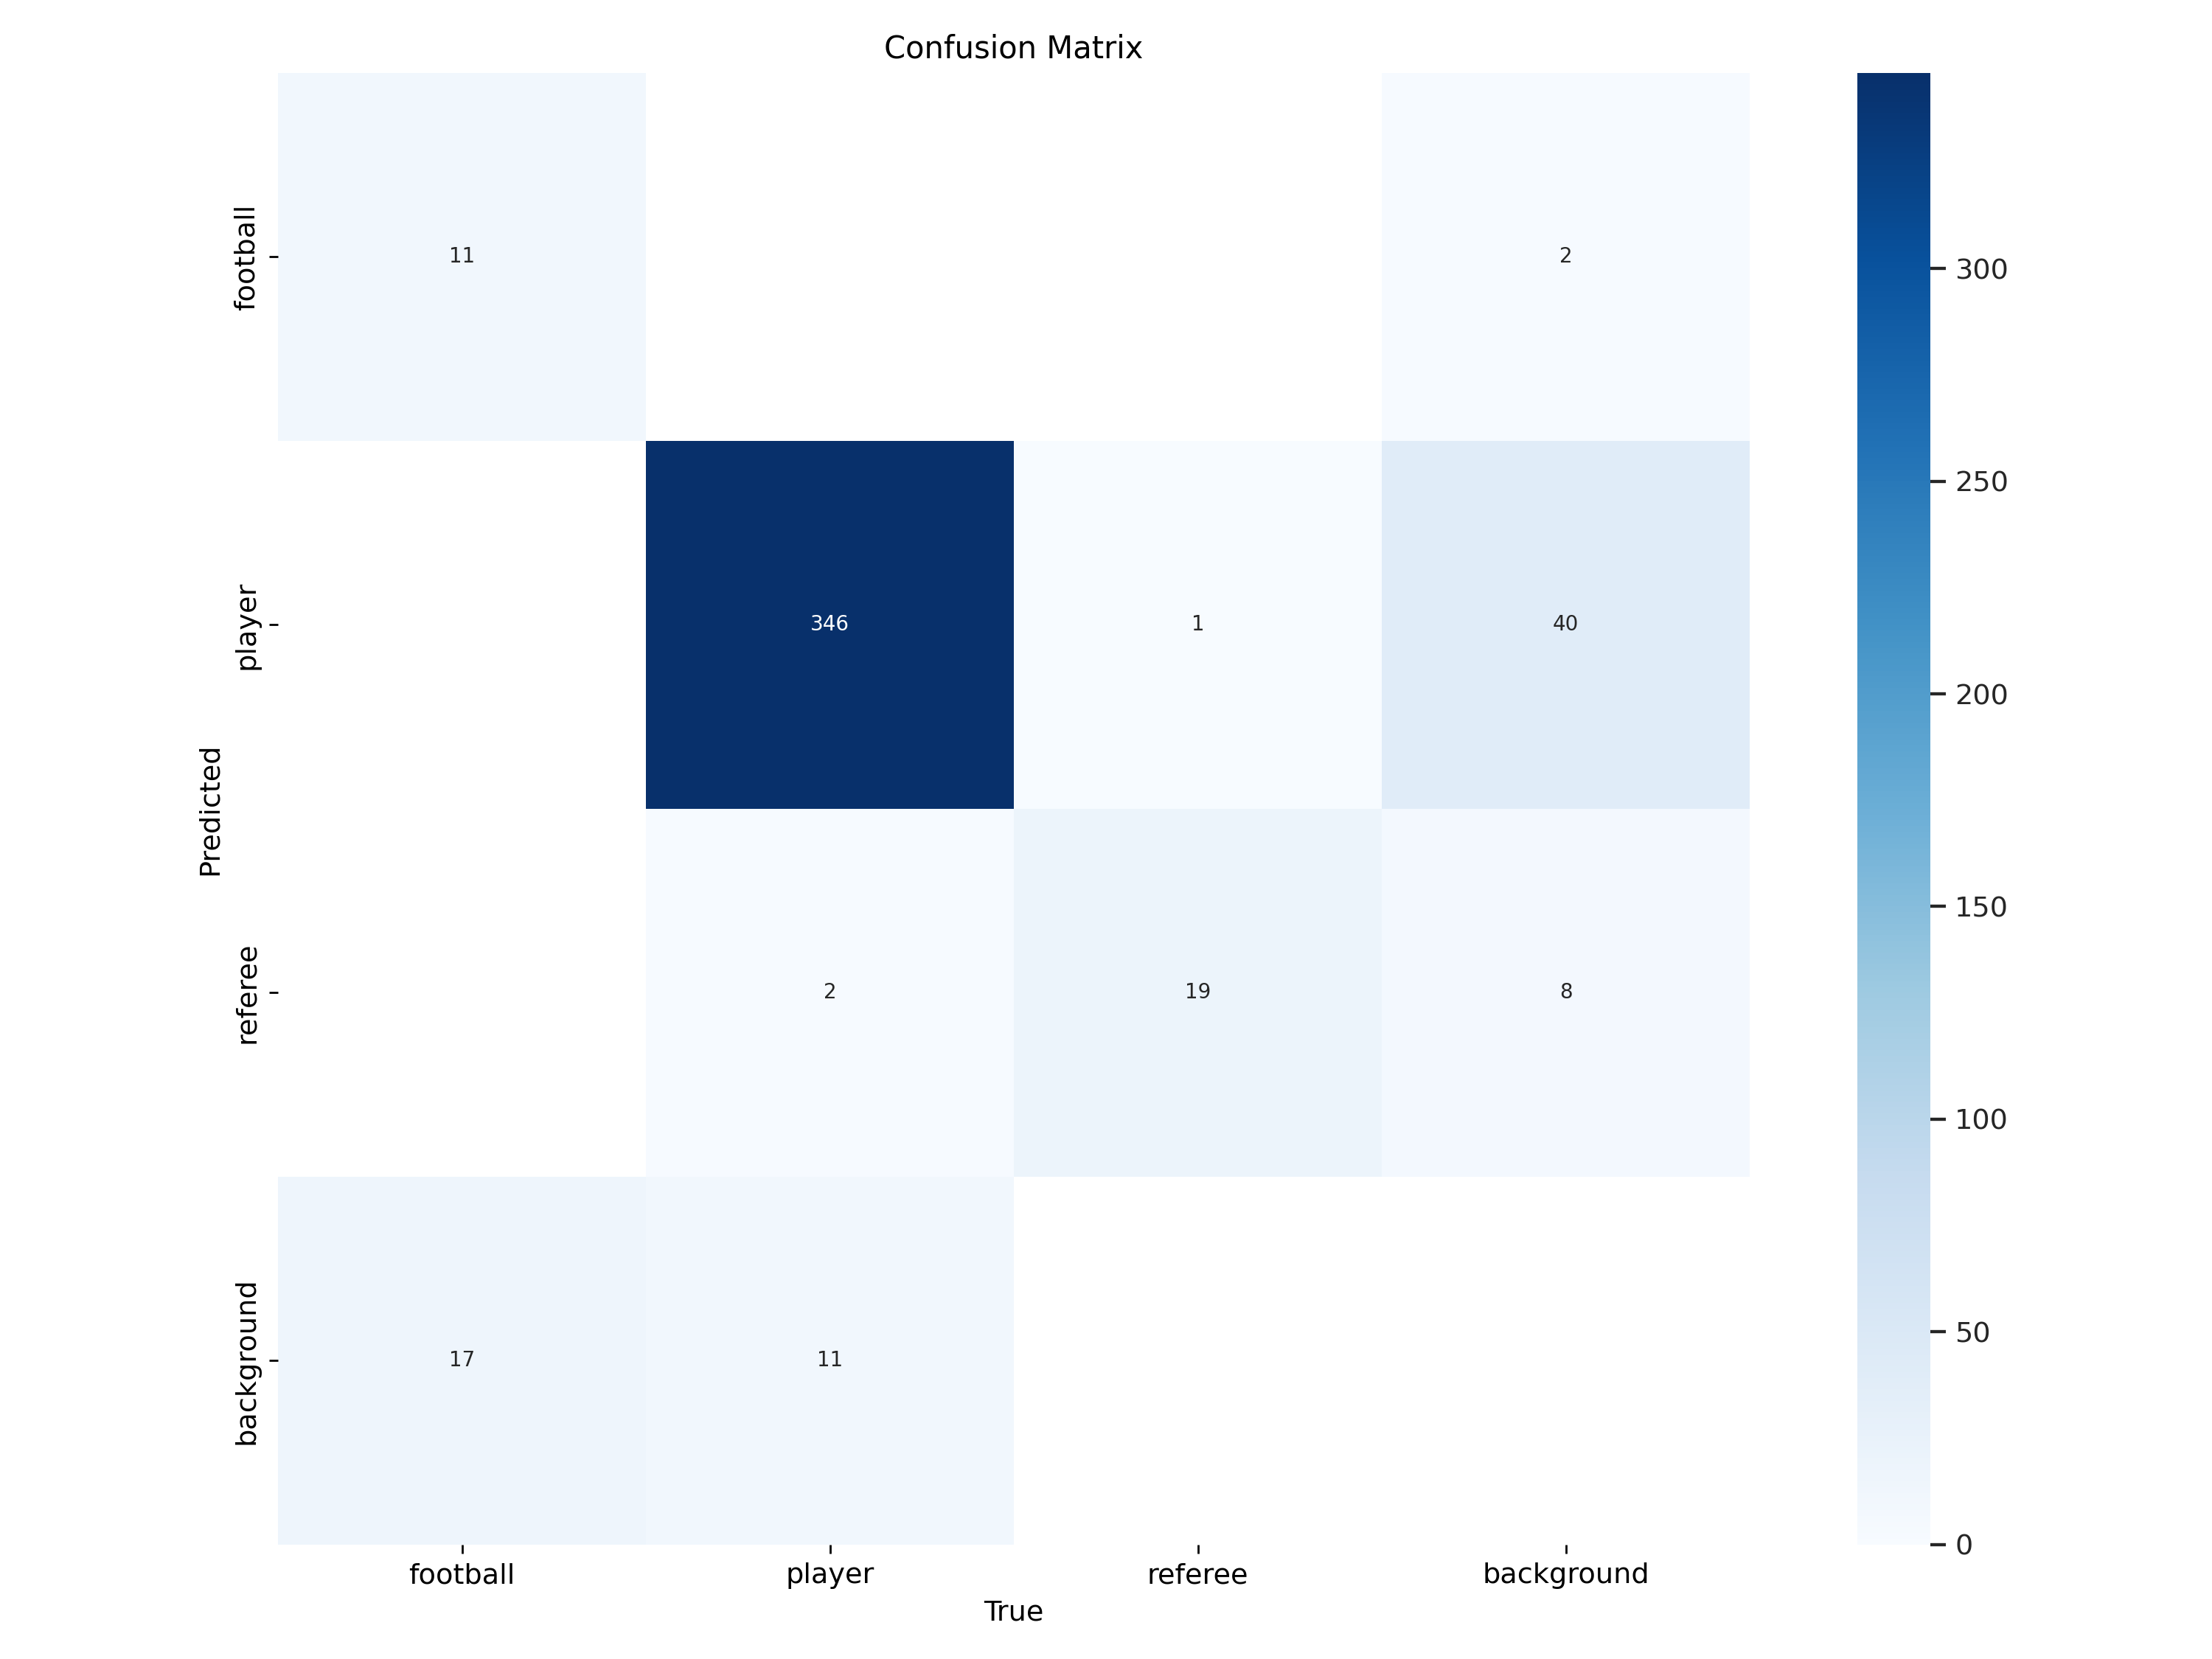

In [13]:
from IPython.display import Image

Image(filename=f'{HOME}/runs/detect/train/confusion_matrix.png', width=1000)

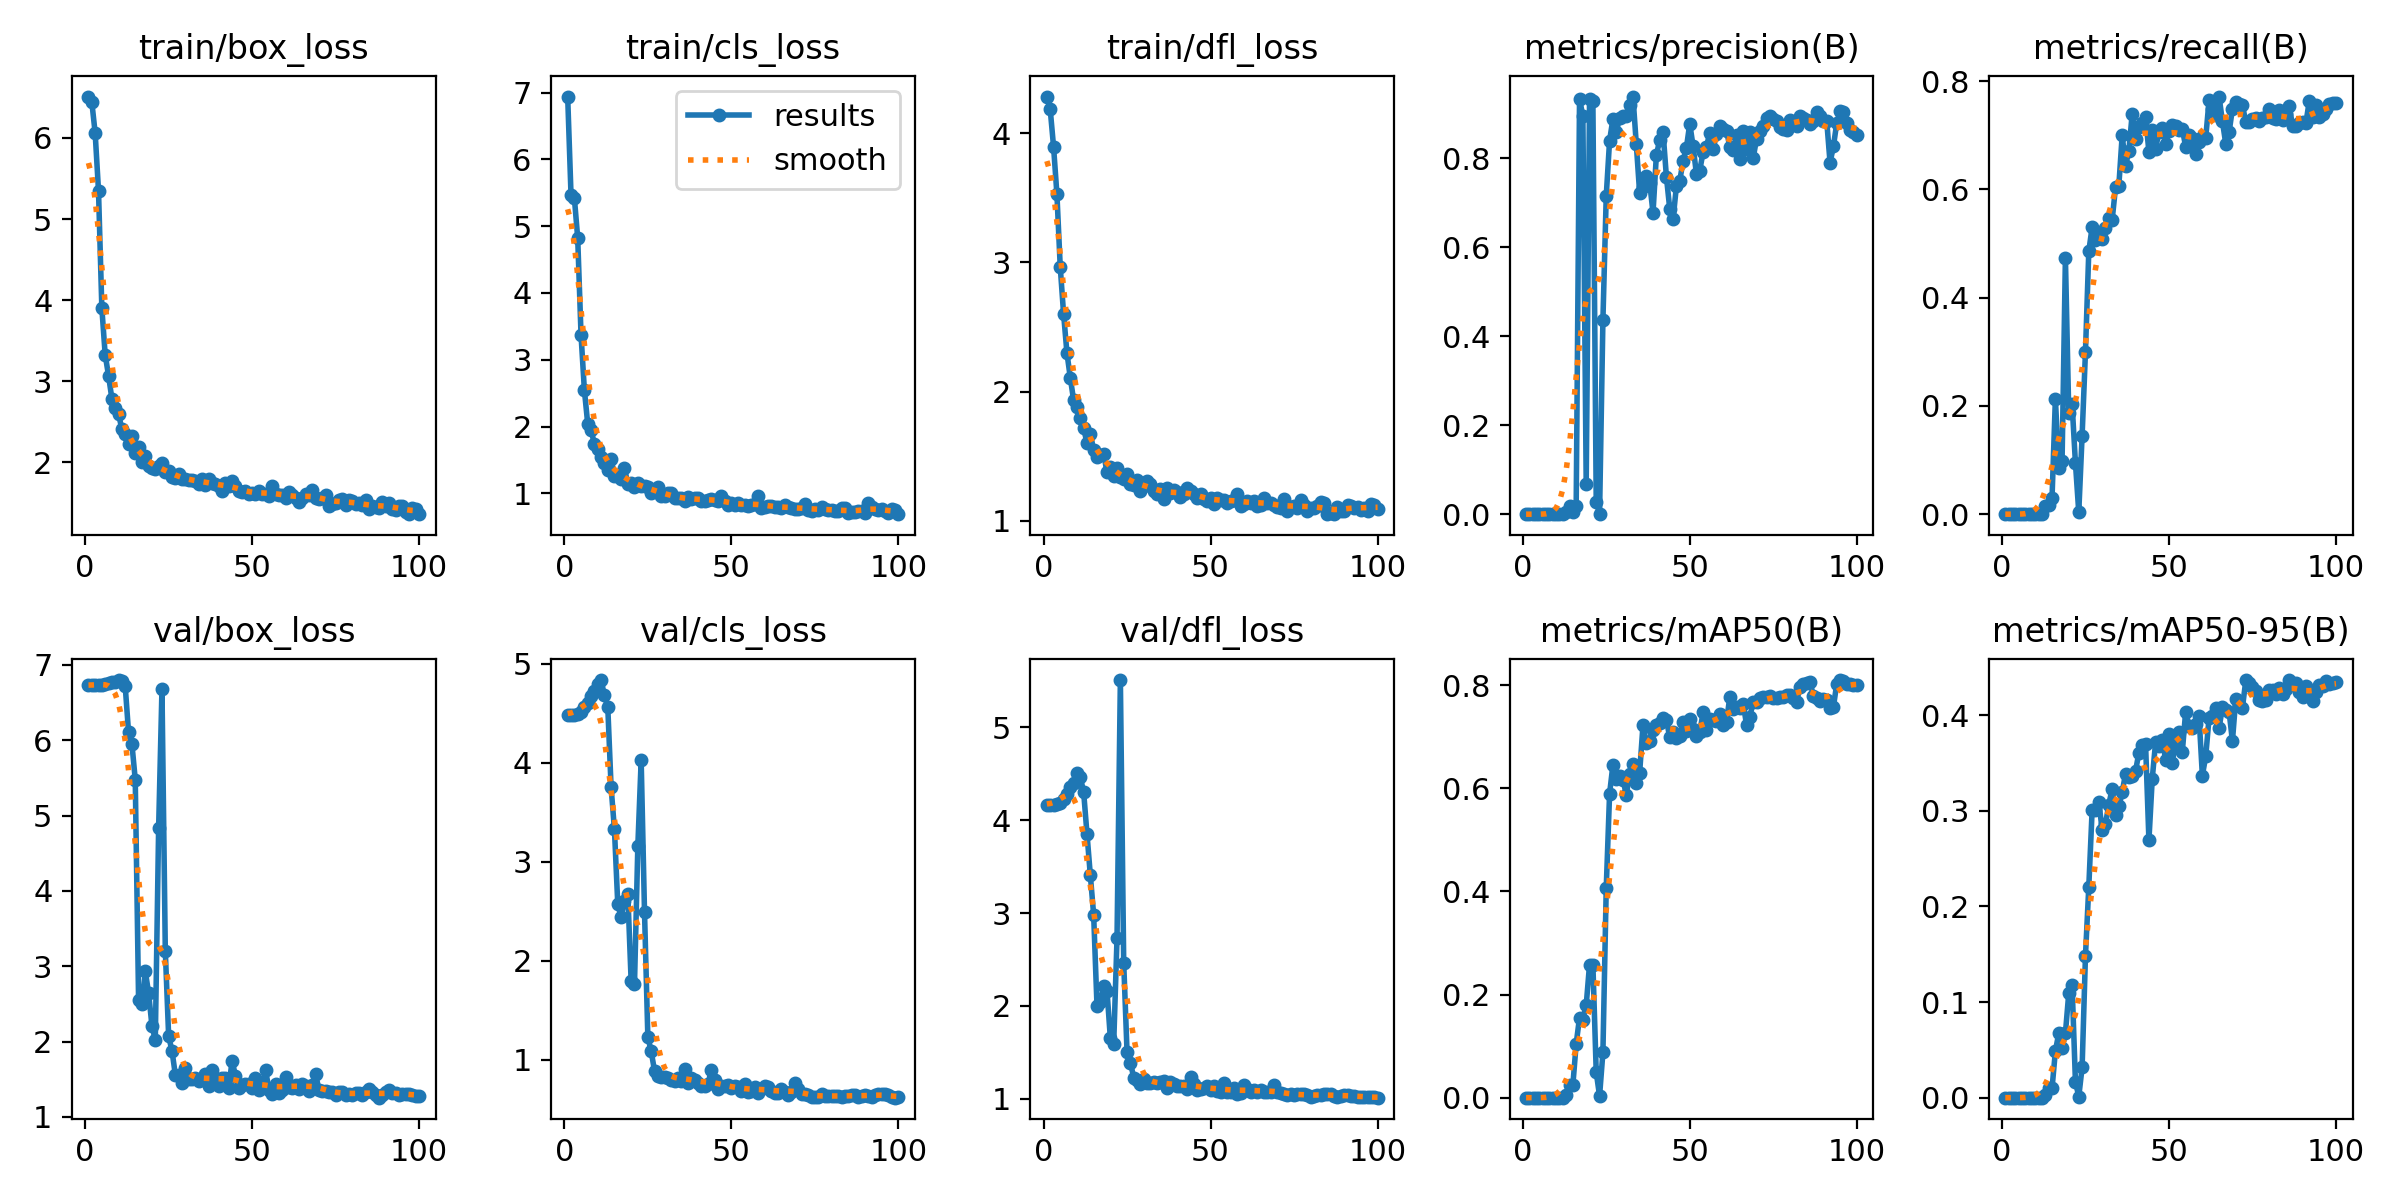

In [14]:
from IPython.display import Image

Image(filename=f'{HOME}/runs/detect/train/results.png', width=1000)

In [15]:
import supervision as sv

ds = sv.DetectionDataset.from_yolo(
    images_directory_path=f"{dataset.location}/test/images",
    annotations_directory_path=f"{dataset.location}/test/labels",
    data_yaml_path=f"{dataset.location}/data.yaml"
)

ds.classes

['football', 'player', 'referee']

In [16]:
from supervision.metrics import MeanAveragePrecision

model = YOLO(f'/{HOME}/runs/detect/train/weights/best.pt')

predictions = []
targets = []

for _, image, target in ds:
    results = model(image, verbose=False)[0]
    detections = sv.Detections.from_ultralytics(results)

    predictions.append(detections)
    targets.append(target)

map = MeanAveragePrecision().update(predictions, targets).compute()

In [17]:
print("mAP 50:95", map.map50_95)
print("mAP 50", map.map50)
print("mAP 75", map.map75)

mAP 50:95 0.3835292734765907
mAP 50 0.6975613931273313
mAP 75 0.4124408459646121


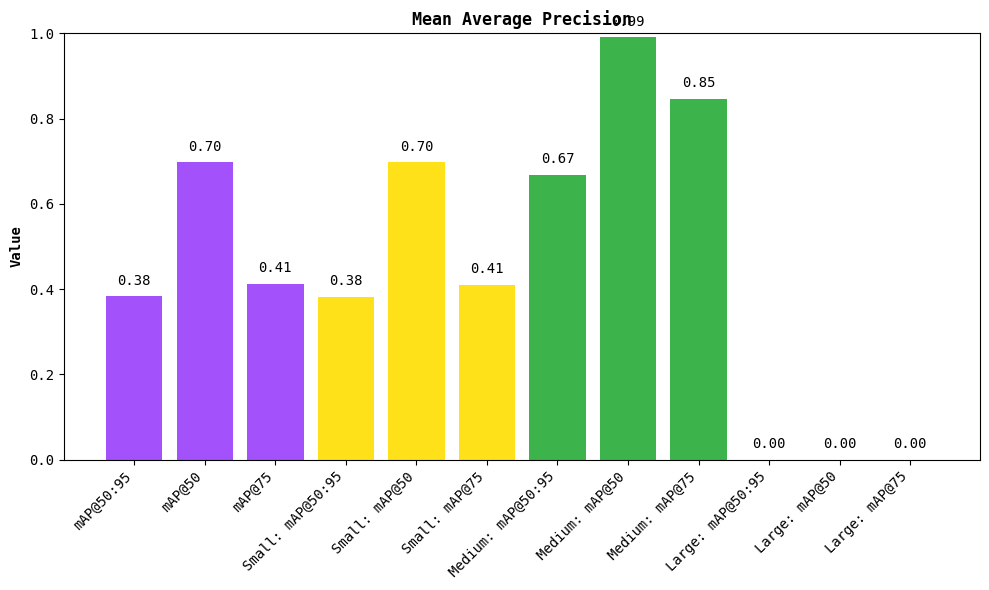

In [18]:
map.plot()

## Почему Large 0.00

In [19]:
import os
import cv2
import supervision as sv
import numpy as np
import builtins

test_dir = "/content/soccer-players-2/test"
images_dir = os.path.join(test_dir, "images")
labels_dir = os.path.join(test_dir, "labels")

# Критерии размеров (в пикселях²) по стандарту COCO
SMALL_THRESHOLD = 1024  # < 32x32
MEDIUM_THRESHOLD = 9216  # 32x32 to 96x96
LARGE_THRESHOLD = 9216  # > 96x96

small_count = 0
medium_count = 0
large_count = 0
total_objects = 0

for label_file in os.listdir(labels_dir):
    if not label_file.endswith(".txt"):
        continue

    label_path = os.path.join(labels_dir, label_file)

    with open(label_path, "r") as f:
        lines = f.readlines()

    image_file = label_file.replace(".txt", ".jpg")
    image_path = os.path.join(images_dir, image_file)

    image = cv2.imread(image_path)
    if image is None:
        continue
    height, width = image.shape[:2]

    # Обрабатываем каждую аннотацию
    for line in lines:
        parts = line.strip().split()
        if len(parts) != 5:
            continue

        # Извлекаем координаты bounding box'а (в нормализованном формате YOLO)
        # Используем builtins.map вместо map, чтобы избежать конфликта
        _, x_center, y_center, bbox_width, bbox_height = list(builtins.map(float, parts))

        # Преобразуем нормализованные координаты в абсолютные (в пикселях)
        x_center = x_center * width
        y_center = y_center * height
        bbox_width = bbox_width * width
        bbox_height = bbox_height * height

        # Вычисляем площадь bounding box'а
        area = bbox_width * bbox_height

        if area < SMALL_THRESHOLD:
            small_count += 1
        elif SMALL_THRESHOLD <= area <= MEDIUM_THRESHOLD:
            medium_count += 1
        else:
            large_count += 1

        total_objects += 1

print(f"Всего объектов: {total_objects}")
print(f"Маленькие объекты (Small, < {SMALL_THRESHOLD} px²): {small_count}")
print(f"Средние объекты (Medium, {SMALL_THRESHOLD}-{MEDIUM_THRESHOLD} px²): {medium_count}")
print(f"Крупные объекты (Large, > {LARGE_THRESHOLD} px²): {large_count}")

if total_objects > 0:
    print(f"Процент Small: {small_count / total_objects * 100:.2f}%")
    print(f"Процент Medium: {medium_count / total_objects * 100:.2f}%")
    print(f"Процент Large: {large_count / total_objects * 100:.2f}%")
else:
    print("Объектов не найдено.")

Всего объектов: 194
Маленькие объекты (Small, < 1024 px²): 184
Средние объекты (Medium, 1024-9216 px²): 10
Крупные объекты (Large, > 9216 px²): 0
Процент Small: 94.85%
Процент Medium: 5.15%
Процент Large: 0.00%


### Потому что больших объекто нет в датасете

Small: Модель показывает умеренную производительность для маленьких объектов (mAP@50:95 = 0.38, mAP@50 = 0.70). Это неплохой результат, учитывая, что маленькие объекты составляют 94.85% датасета, и их сложнее детектировать из-за низкого разрешения.

Medium: Для средних объектов модель показывает лучшие результаты (mAP@50:95 = 0.41, mAP@75 = 0.67), что логично, так как средние объекты легче детектировать, чем маленькие. Однако их всего 10, так что вклад этой категории в общий mAP невелик.

Large: Как мы выяснили, крупных объектов нет, поэтому mAP = 0.00.

In [20]:
model = YOLO(f'/{HOME}/runs/detect/train/weights/best.pt')

ds = sv.DetectionDataset.from_yolo(
    images_directory_path=f"{dataset.location}/test/images",
    annotations_directory_path=f"{dataset.location}/test/labels",
    data_yaml_path=f"{dataset.location}/data.yaml"
)

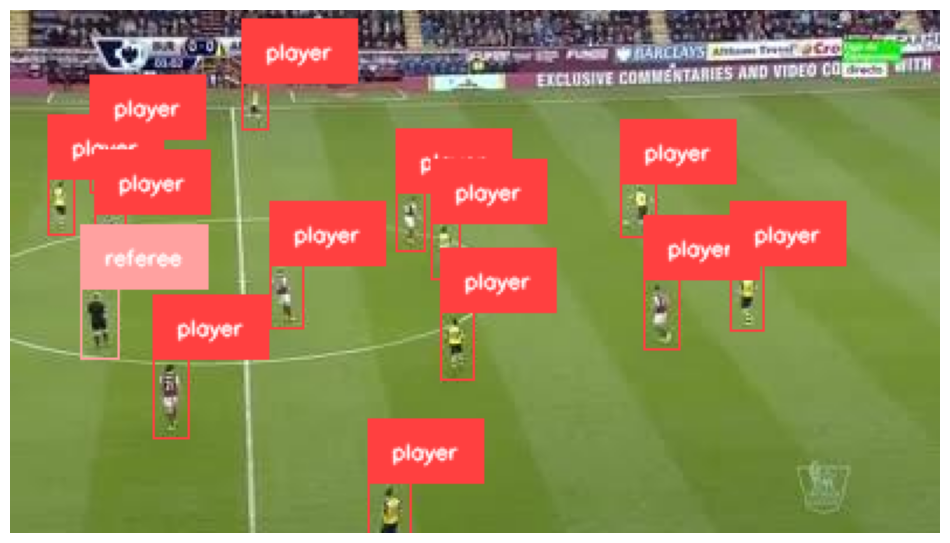

In [28]:
import random
import supervision as sv

i = random.randint(0, len(ds))
image_path, image, target = ds[i]

results = model(image, verbose=False)[0]
detections = sv.Detections.from_ultralytics(results).with_nms()

box_annotator = sv.BoxAnnotator(
    thickness=1
)

label_annotator = sv.LabelAnnotator(
    text_scale=0.3,
    text_thickness=1
)

annotated_image = image.copy()
annotated_image = box_annotator.annotate(scene=annotated_image, detections=detections)
annotated_image = label_annotator.annotate(scene=annotated_image, detections=detections)

sv.plot_image(annotated_image)

## **Задание 3. Сформируйте свой датасет для детекции объектов и обучите на нем модель YOLOv12**



Требования к датасету:

- Количество изображений в датасете: минимум 90
- Количество классов: более 2х
- Обязательно должны присутствовать изображения, содержащие несколько классов одновременно


*Примечание: Формирование датасета включает в себя поиск изображений и ручное аннотирование объектов на изображениях.*

In [30]:
from roboflow import Roboflow
rf = Roboflow(api_key=userdata.get("ROBOFLOW_API_KEY"))
dataset = download_dataset('https://app.roboflow.com/neuralnetworksyolo/barca-vs-inter-2025/1', 'yolov12')

loading Roboflow workspace...
loading Roboflow project...
Exporting format yolov12 in progress : 85.0%
Version export complete for yolov12 format



Extracting Dataset Version Zip to Barca-vs-Inter-2025-1 in yolov12:: 100%|██████████| 200/200 [00:00<00:00, 3191.55it/s]


In [31]:
!ls {dataset.location}

data.yaml  README.dataset.txt  README.roboflow.txt  test  train  valid


In [33]:
!sed -i '$d' {dataset.location}/data.yaml
!sed -i '$d' {dataset.location}/data.yaml
!sed -i '$d' {dataset.location}/data.yaml
!sed -i '$d' {dataset.location}/data.yaml
!echo -e "test: ../test/images\ntrain: ../train/images\nval: ../valid/images" >> {dataset.location}/data.yaml

In [34]:
!cat {dataset.location}/data.yaml

train: ../train/images
val: ../valid/images
test: ../test/images

nc: 6
names: ['Ball', 'Barca goalkeeper', 'Barca player', 'Inter goalkeeper', 'Inter player', 'Ref']

roboflow:
test: ../test/images
train: ../train/images
val: ../valid/images


In [35]:
from ultralytics import YOLO

model = YOLO('yolov12s.yaml')

results = model.train(data=f'{dataset.location}/data.yaml', epochs=100)

New https://pypi.org/project/ultralytics/8.3.128 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.3.63 🚀 Python-3.11.12 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: task=detect, mode=train, model=yolov12s.yaml, data=/content/Barca-vs-Inter-2025-1/data.yaml, epochs=100, time=None, patience=100, batch=16, imgsz=640, save=True, save_period=-1, cache=False, device=None, workers=8, project=None, name=train2, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show

train: Scanning /content/Barca-vs-Inter-2025-1/train/labels... 64 images, 0 backgrounds, 0 corrupt: 100%|██████████| 64/64 [00:00<00:00, 2015.86it/s]

train: New cache created: /content/Barca-vs-Inter-2025-1/train/labels.cache
albumentations: Blur(p=0.01, blur_limit=(3, 7)), MedianBlur(p=0.01, blur_limit=(3, 7)), ToGray(p=0.01, method='weighted_average', num_output_channels=3), CLAHE(p=0.01, clip_limit=(1.0, 4.0), tile_grid_size=(8, 8))



val: Scanning /content/Barca-vs-Inter-2025-1/valid/labels... 11 images, 0 backgrounds, 0 corrupt: 100%|██████████| 11/11 [00:00<00:00, 1272.33it/s]

val: New cache created: /content/Barca-vs-Inter-2025-1/valid/labels.cache


...

    100/100       6.7G       2.17      1.367      1.538        270        640: 100%|██████████| 4/4 [00:02<00:00,  1.92it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 1/1 [00:00<00:00,  7.05it/s]

                   all         11        197      0.764      0.607      0.575      0.229



100 epochs completed in 0.098 hours.
Optimizer stripped from runs/detect/train2/weights/last.pt, 18.6MB
Optimizer stripped from runs/detect/train2/weights/best.pt, 18.6MB

Validating runs/detect/train2/weights/best.pt...
Ultralytics 8.3.63 🚀 Python-3.11.12 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
YOLOv12s summary (fused): 376 layers, 9,076,530 parameters, 0 gradients, 19.3 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 1/1 [00:00<00:00,  6.81it/s]


                   all         11        197      0.706      0.543       0.56      0.235
                  Ball          9          9          1          0     0.0443    0.00443
          Barca player         11         81      0.836      0.864      0.876      0.361
      Inter goalkeeper          3          3      0.343      0.333      0.355      0.214
          Inter player         11         83      0.629      0.783      0.735      0.223
                   Ref         11         21       0.72      0.736      0.791      0.374
Speed: 0.1ms preprocess, 4.2ms inference, 0.0ms loss, 1.3ms postprocess per image
Results saved to runs/detect/train2


In [36]:
import locale
locale.getpreferredencoding = lambda: "UTF-8"

!ls {HOME}/runs/detect/train2/

args.yaml					   results.png
confusion_matrix_normalized.png			   train_batch0.jpg
confusion_matrix.png				   train_batch1.jpg
events.out.tfevents.1746572145.a06ffb3ef857.981.1  train_batch2.jpg
F1_curve.png					   train_batch360.jpg
labels_correlogram.jpg				   train_batch361.jpg
labels.jpg					   train_batch362.jpg
P_curve.png					   val_batch0_labels.jpg
PR_curve.png					   val_batch0_pred.jpg
R_curve.png					   weights
results.csv


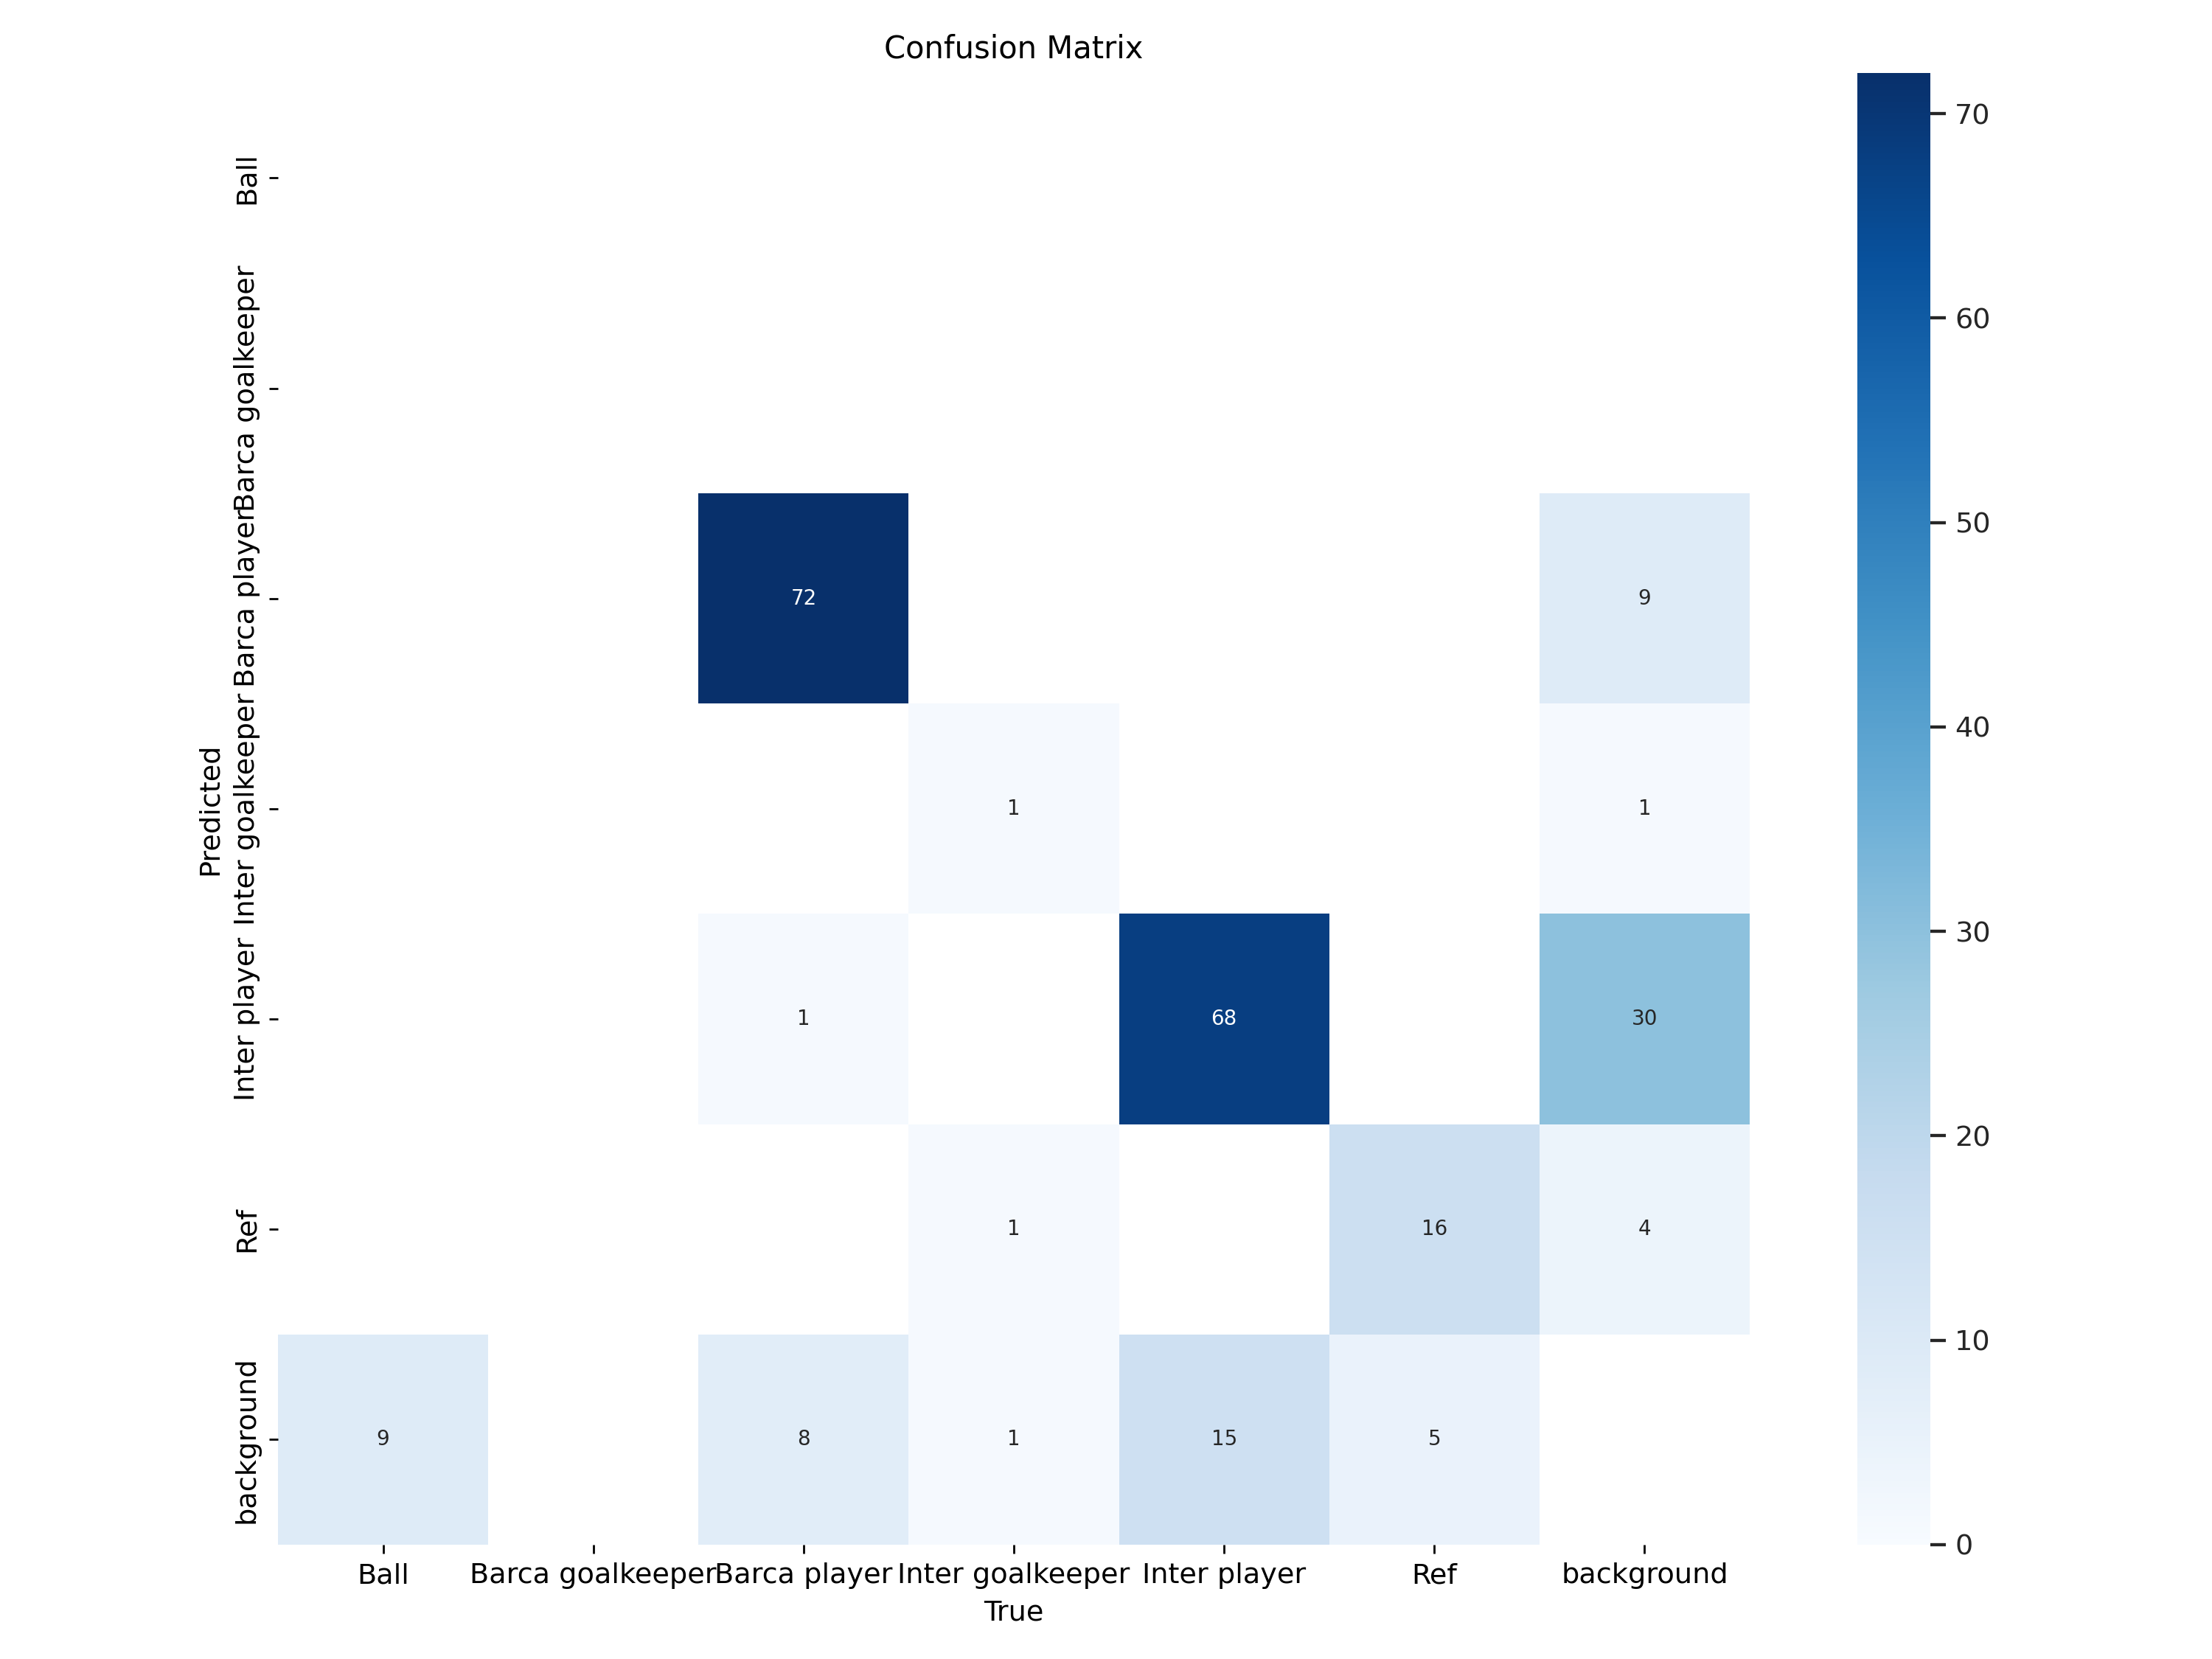

In [37]:
from IPython.display import Image

Image(filename=f'{HOME}/runs/detect/train2/confusion_matrix.png', width=1000)

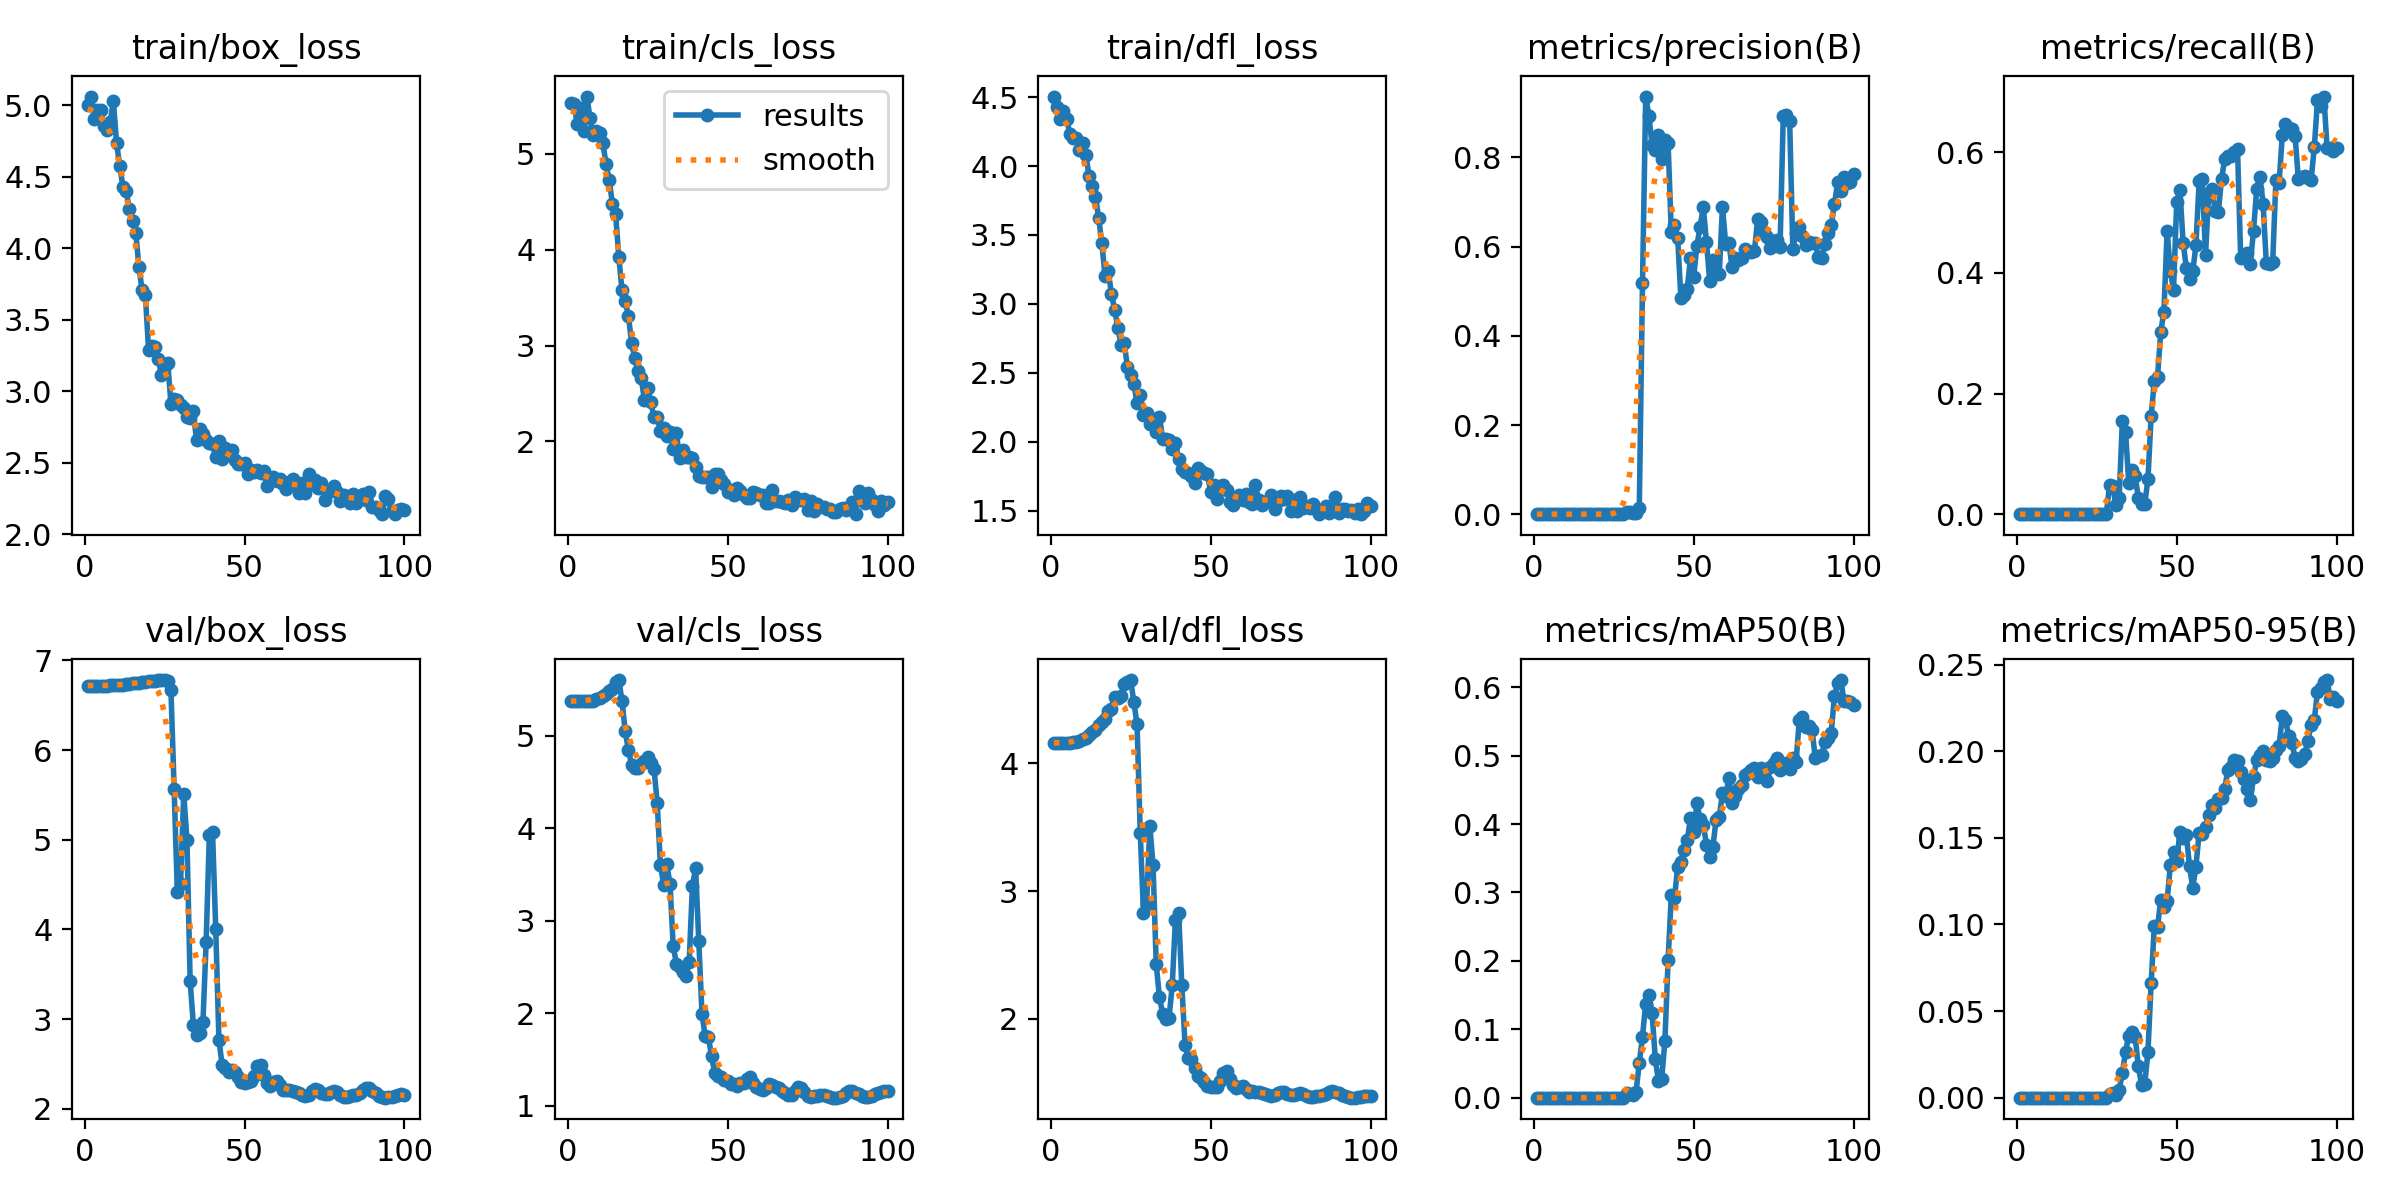

In [38]:
from IPython.display import Image

Image(filename=f'{HOME}/runs/detect/train2/results.png', width=1000)

In [39]:
import supervision as sv

ds = sv.DetectionDataset.from_yolo(
    images_directory_path=f"{dataset.location}/test/images",
    annotations_directory_path=f"{dataset.location}/test/labels",
    data_yaml_path=f"{dataset.location}/data.yaml"
)

ds.classes

['Ball',
 'Barca goalkeeper',
 'Barca player',
 'Inter goalkeeper',
 'Inter player',
 'Ref']

In [40]:
import supervision as sv

model = YOLO(f'/{HOME}/runs/detect/train2/weights/best.pt')

ds = sv.DetectionDataset.from_yolo(
    images_directory_path=f"{dataset.location}/test/images",
    annotations_directory_path=f"{dataset.location}/test/labels",
    data_yaml_path=f"{dataset.location}/data.yaml"
)

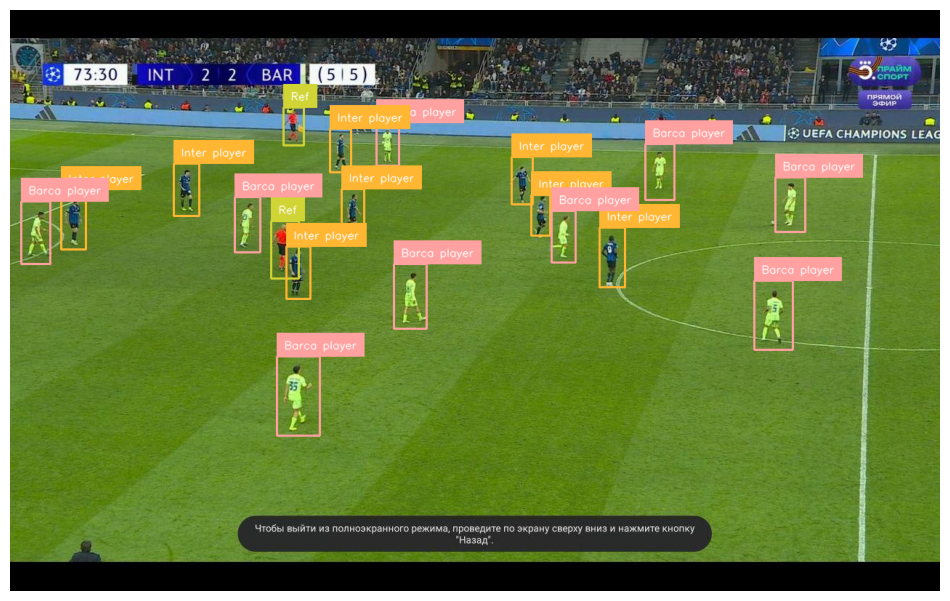

In [41]:
import random

i = random.randint(0, len(ds))

image_path, image, target = ds[i]

results = model(image, verbose=False)[0]
detections = sv.Detections.from_ultralytics(results).with_nms()

box_annotator = sv.BoxAnnotator()
label_annotator = sv.LabelAnnotator()

annotated_image = image.copy()
annotated_image = box_annotator.annotate(scene=annotated_image, detections=detections)
annotated_image = label_annotator.annotate(scene=annotated_image, detections=detections)


sv.plot_image(annotated_image)

## **Задание 4 (для магистрантов). Обучите модель YOLOv12 на датасете [RSD-GOD](https://github.com/Dr-Zhuang/geospatial-object-detection). Затем самостоятельно сформируйте тестовые данные (не менее 50 изображений с аннотациями) и оцените качество обученной модели:**



**Прямая ссылка на загрузку датасета: [загрузить](https://drive.google.com/open?id=1ttvSta0BRxW7tTV_st89vSb_obHVre34)**

 *Примечание: для поиска данных удобно использовать сервис Google Earth/Google Earth Engine*

In [42]:
from roboflow import Roboflow
from google.colab import userdata
rf = Roboflow(api_key=userdata.get("ROBOFLOW_API_KEY"))
project = rf.workspace("yololab-ca1yx").project("rsd-god-ryzup")
dataset = project.version(1).download("yolov8")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to rsd-god-1 in yolov8:: 100%|██████████| 10196/10196 [00:02<00:00, 3649.74it/s]


In [43]:
!ls {dataset.location}

data.yaml  README.dataset.txt  README.roboflow.txt  test  train  valid


In [44]:
!sed -i '$d' {dataset.location}/data.yaml
!sed -i '$d' {dataset.location}/data.yaml
!sed -i '$d' {dataset.location}/data.yaml
!sed -i '$d' {dataset.location}/data.yaml
!echo -e "test: ../test/images\ntrain: ../train/images\nval: ../valid/images" >> {dataset.location}/data.yaml

In [45]:
!cat {dataset.location}/data.yaml

names:
- airport
- helicopter
- oiltank
- plane
- warship
nc: 5
roboflow:
  license: CC BY 4.0
  project: rsd-god-ryzup
  url: https://universe.roboflow.com/yololab-ca1yx/rsd-god-ryzup/dataset/1
  version: 1
test: ../test/images
train: ../train/images
val: ../valid/images


In [46]:
from ultralytics import YOLO

model = YOLO('yolov12s.yaml')

results = model.train(data=f'{dataset.location}/data.yaml', epochs=25)

New https://pypi.org/project/ultralytics/8.3.128 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.3.63 🚀 Python-3.11.12 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: task=detect, mode=train, model=yolov12s.yaml, data=/content/rsd-god-1/data.yaml, epochs=25, time=None, patience=100, batch=16, imgsz=640, save=True, save_period=-1, cache=False, device=None, workers=8, project=None, name=train3, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=False, save_

train: Scanning /content/rsd-god-1/train/labels... 3564 images, 0 backgrounds, 0 corrupt: 100%|██████████| 3564/3564 [00:01<00:00, 2405.57it/s]


train: New cache created: /content/rsd-god-1/train/labels.cache
albumentations: Blur(p=0.01, blur_limit=(3, 7)), MedianBlur(p=0.01, blur_limit=(3, 7)), ToGray(p=0.01, method='weighted_average', num_output_channels=3), CLAHE(p=0.01, clip_limit=(1.0, 4.0), tile_grid_size=(8, 8))


val: Scanning /content/rsd-god-1/valid/labels... 1019 images, 0 backgrounds, 0 corrupt: 100%|██████████| 1019/1019 [00:00<00:00, 1186.82it/s]


val: New cache created: /content/rsd-god-1/valid/labels.cache
Plotting labels to runs/detect/train3/labels.jpg... 
optimizer: 'optimizer=auto' found, ignoring 'lr0=0.01' and 'momentum=0.937' and determining best 'optimizer', 'lr0' and 'momentum' automatically... 
optimizer: AdamW(lr=0.001111, momentum=0.9) with parameter groups 121 weight(decay=0.0), 128 weight(decay=0.0005), 127 bias(decay=0.0)
TensorBoard: model graph visualization added ✅
Image sizes 640 train, 640 val
Using 2 dataloader workers
Logging results to runs/detect/train3
Starting training for 25 epochs...

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size


...

      25/25      6.68G      1.456     0.9739      1.725         43        640: 100%|██████████| 223/223 [01:57<00:00,  1.89it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 32/32 [00:12<00:00,  2.47it/s]

                   all       1019       2332      0.843      0.827      0.883      0.504



25 epochs completed in 0.932 hours.
Optimizer stripped from runs/detect/train3/weights/last.pt, 18.6MB
Optimizer stripped from runs/detect/train3/weights/best.pt, 18.6MB

Validating runs/detect/train3/weights/best.pt...
Ultralytics 8.3.63 🚀 Python-3.11.12 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
YOLOv12s summary (fused): 376 layers, 9,076,143 parameters, 0 gradients, 19.3 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 32/32 [00:15<00:00,  2.11it/s]


                   all       1019       2332      0.842      0.827      0.883      0.504
               airport        226        228      0.768       0.75      0.842      0.462
            helicopter        133        398      0.902      0.955      0.972      0.637
               oiltank        246        617      0.919      0.909      0.953      0.581
                 plane        201        637      0.909      0.851       0.92      0.475
               warship        227        452      0.712      0.671      0.727      0.366
Speed: 0.3ms preprocess, 8.9ms inference, 0.0ms loss, 1.7ms postprocess per image
Results saved to runs/detect/train3


In [47]:
import locale
locale.getpreferredencoding = lambda: "UTF-8"

!ls /content/runs/detect/train3/
model_path = "/content/runs/detect/train3/"

args.yaml					   train_batch1.jpg
confusion_matrix_normalized.png			   train_batch2.jpg
confusion_matrix.png				   train_batch3345.jpg
events.out.tfevents.1746572644.a06ffb3ef857.981.2  train_batch3346.jpg
F1_curve.png					   train_batch3347.jpg
labels_correlogram.jpg				   val_batch0_labels.jpg
labels.jpg					   val_batch0_pred.jpg
P_curve.png					   val_batch1_labels.jpg
PR_curve.png					   val_batch1_pred.jpg
R_curve.png					   val_batch2_labels.jpg
results.csv					   val_batch2_pred.jpg
results.png					   weights
train_batch0.jpg


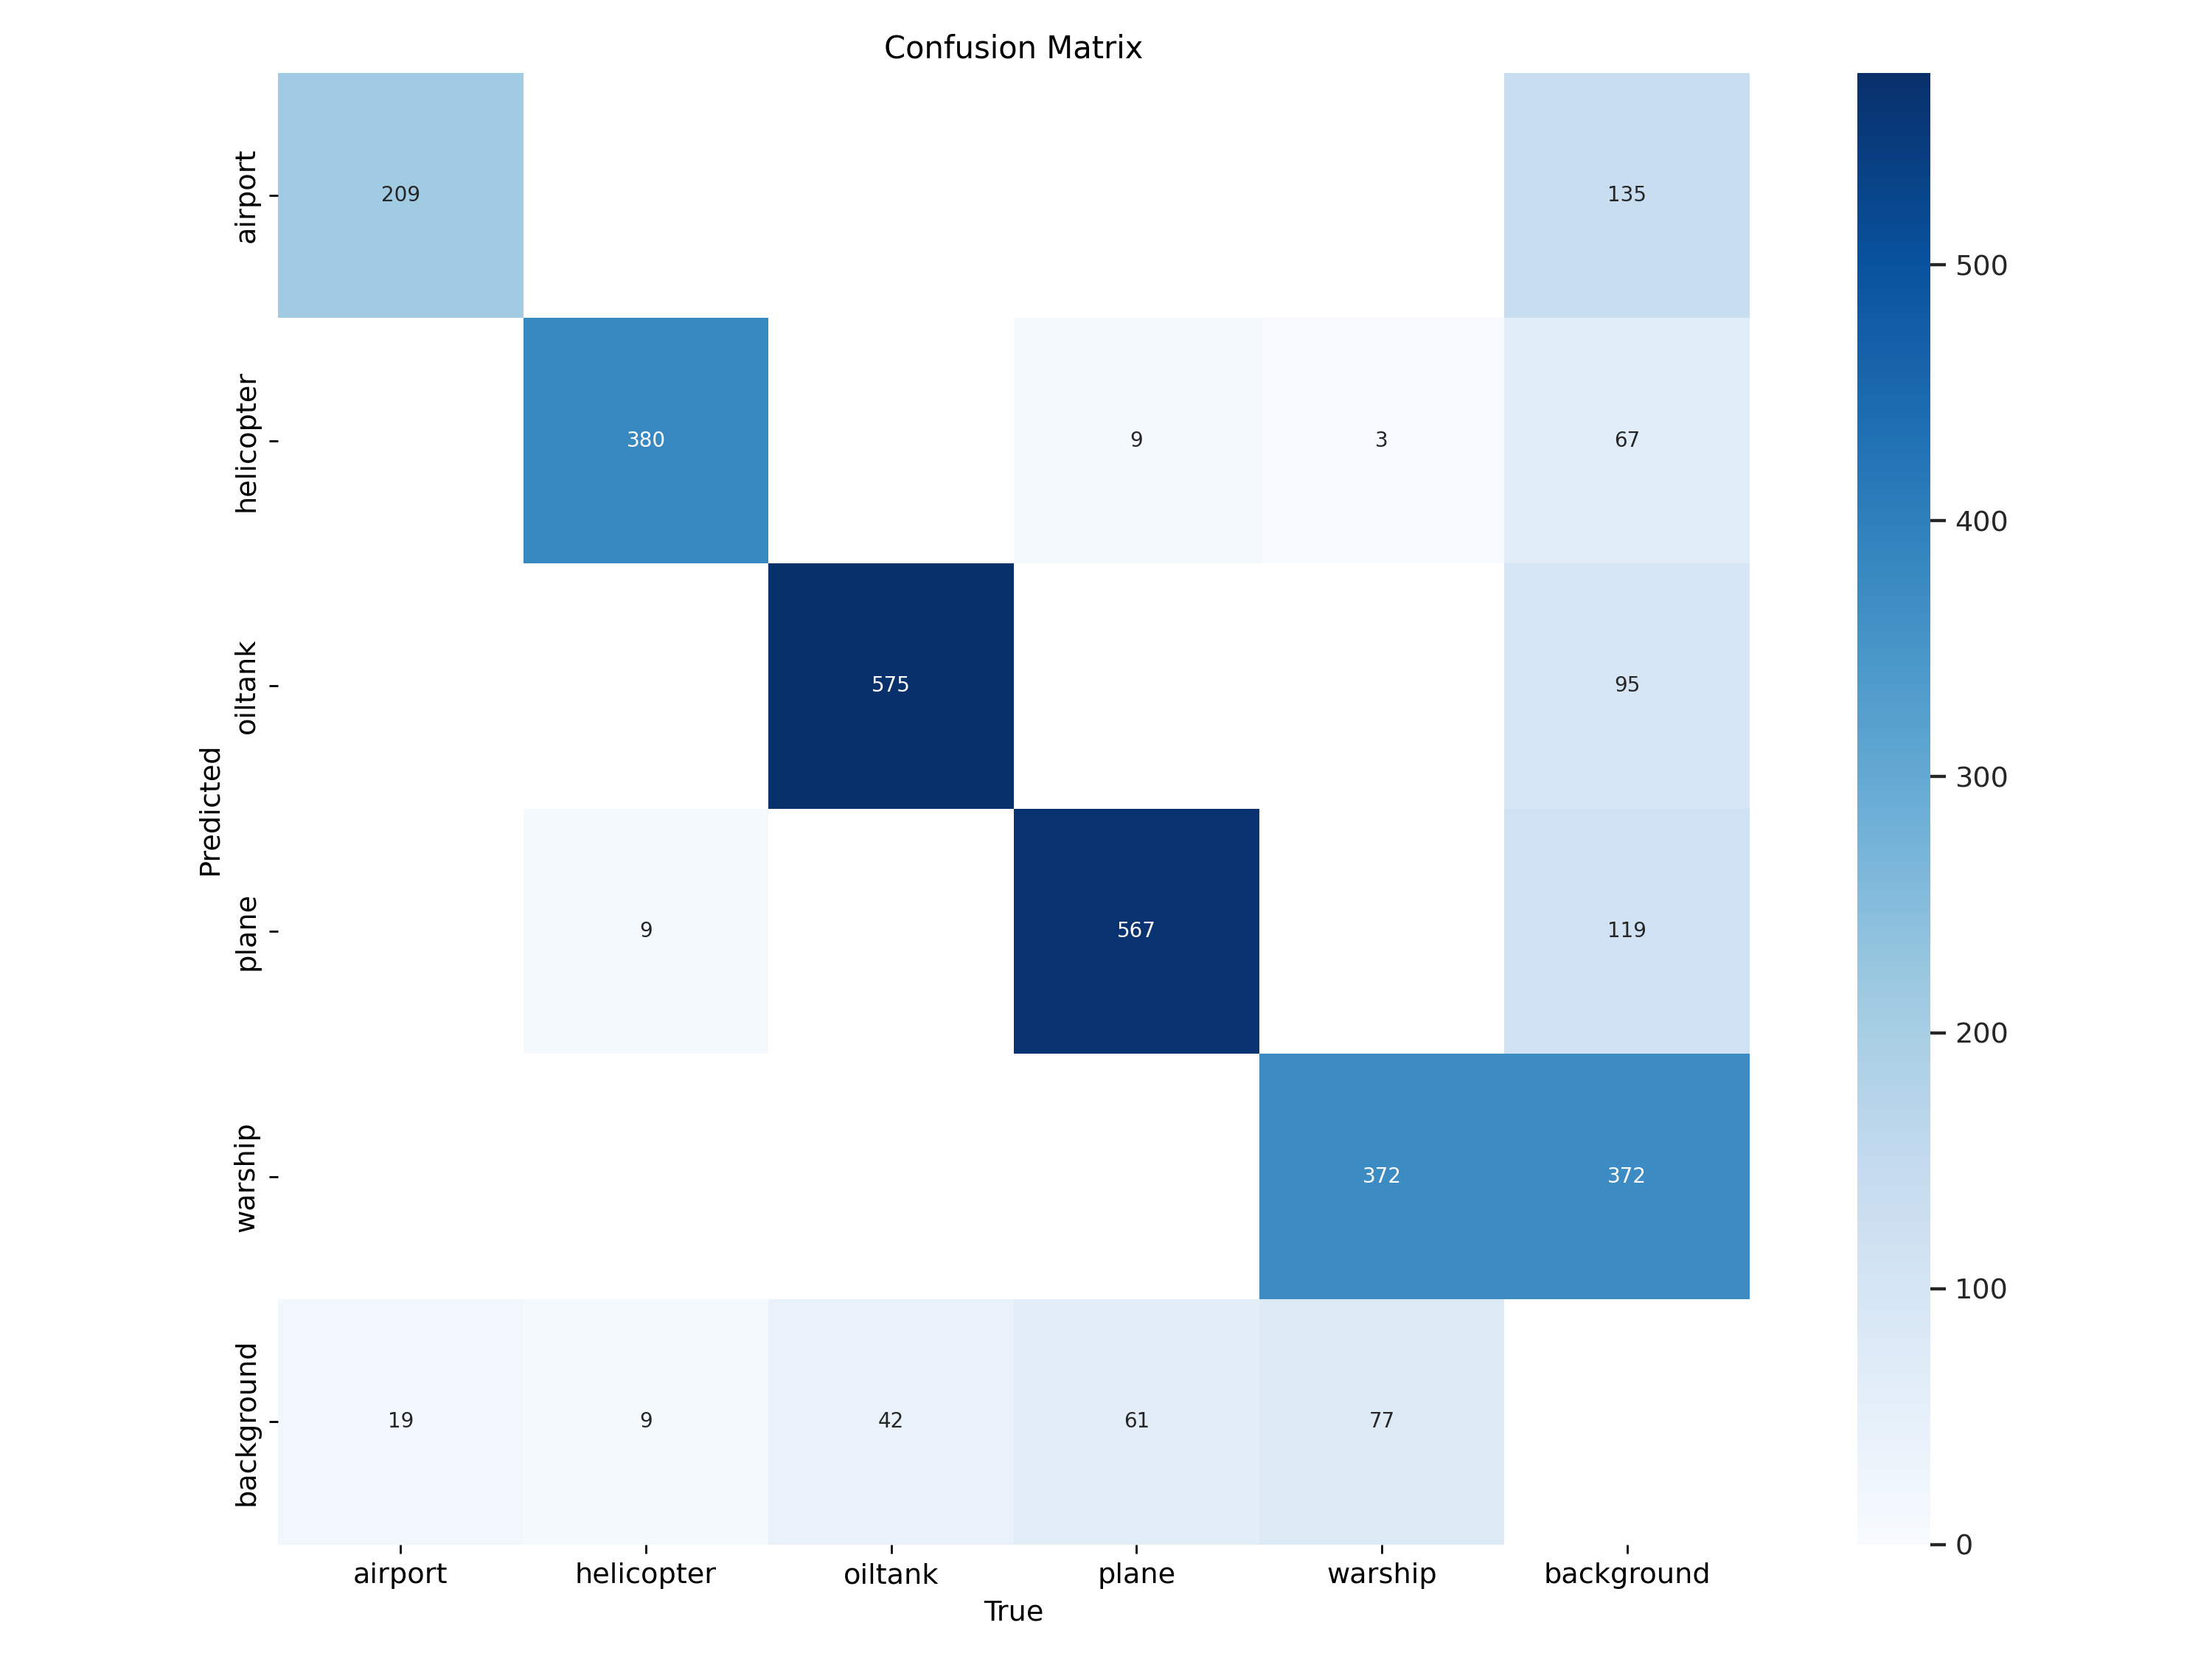

In [48]:
from IPython.display import Image

Image(filename=f'{model_path}confusion_matrix.png', width=1000)

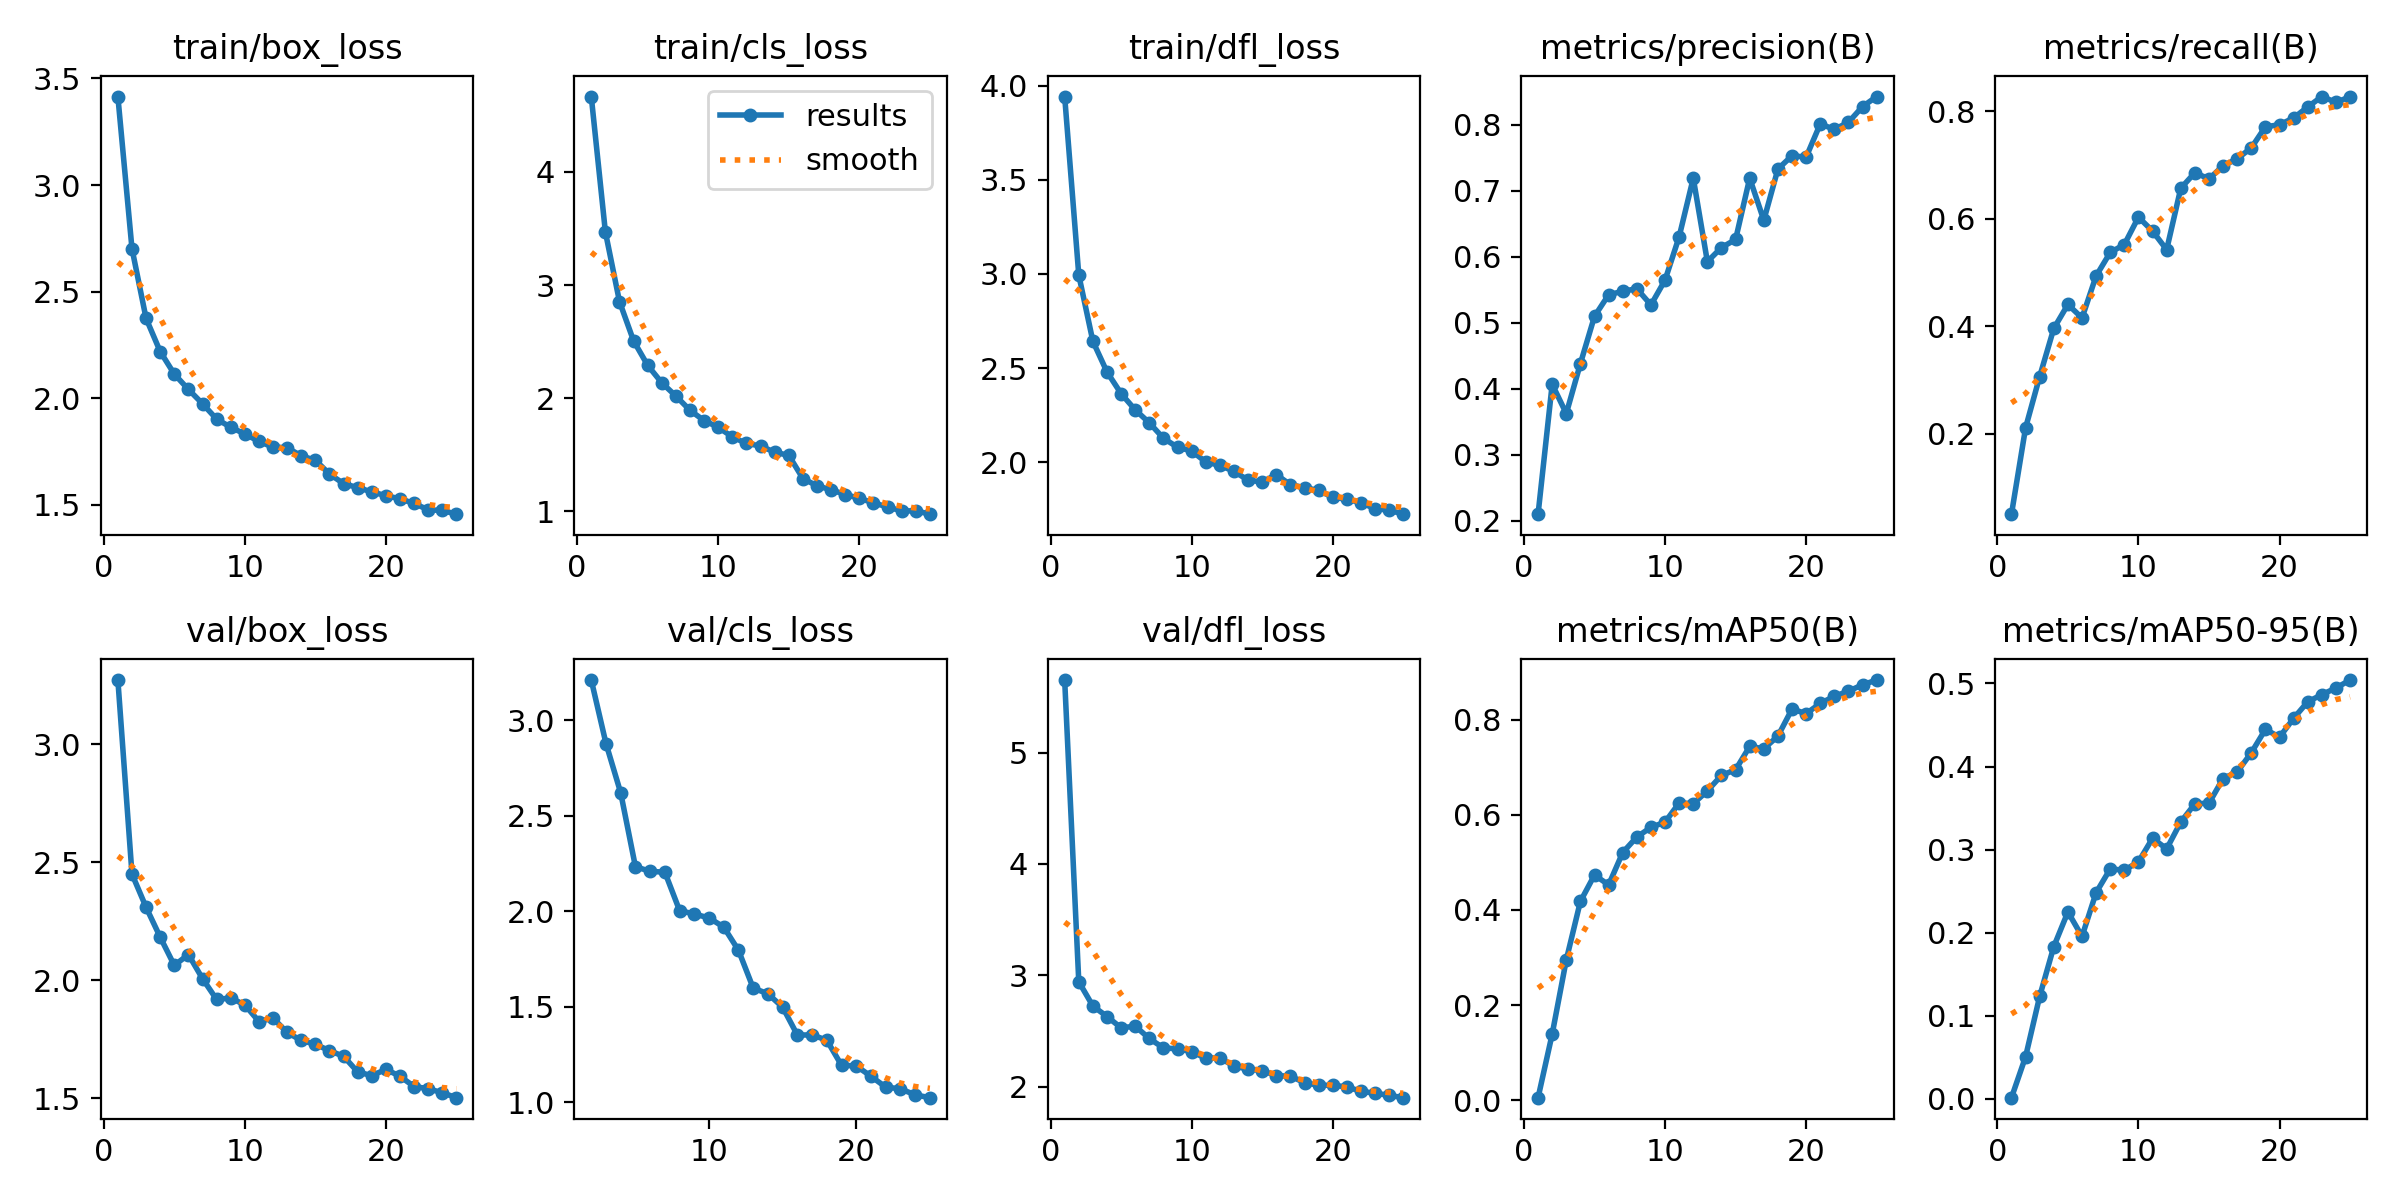

In [49]:
from IPython.display import Image

Image(filename=f'{model_path}results.png', width=1000)

In [50]:
import supervision as sv

model = YOLO(f'{model_path}weights/best.pt')

ds = sv.DetectionDataset.from_yolo(
    images_directory_path=f"{dataset.location}/test/images",
    annotations_directory_path=f"{dataset.location}/test/labels",
    data_yaml_path=f"{dataset.location}/data.yaml"
)

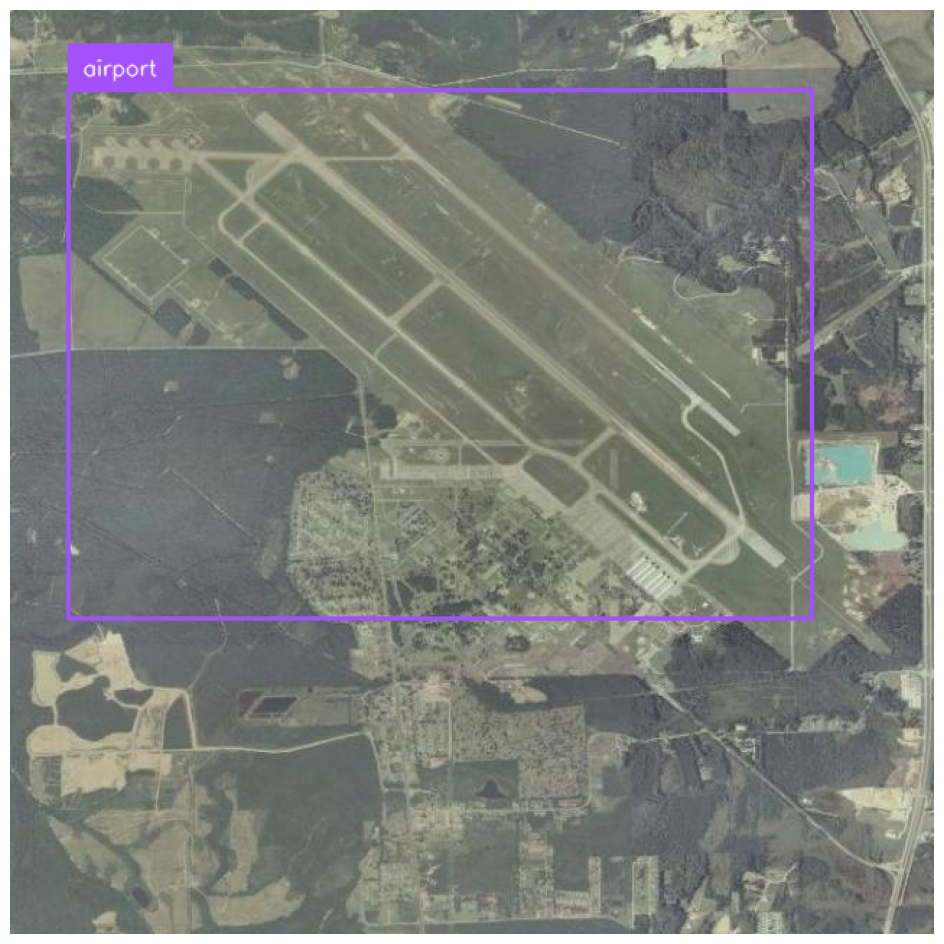

In [51]:
import random

i = random.randint(0, len(ds))

image_path, image, target = ds[i]

results = model(image, verbose=False)[0]
detections = sv.Detections.from_ultralytics(results).with_nms()

box_annotator = sv.BoxAnnotator()
label_annotator = sv.LabelAnnotator()

annotated_image = image.copy()
annotated_image = box_annotator.annotate(scene=annotated_image, detections=detections)
annotated_image = label_annotator.annotate(scene=annotated_image, detections=detections)


sv.plot_image(annotated_image)

In [52]:
!roboflow login

visit https://app.roboflow.com/auth-cli to get your authentication token.
Paste the authentication token here: 


In [53]:
!roboflow upload_model -w neuralnetworksyolo -p rsd-god-whlpq -t yolov12 -m ./runs/detect/train3/

loading Roboflow workspace...
FlashAttention is not available on this device. Using scaled_dot_product_attention instead.

!!! ATTENTION !!!
Model must be trained and uploaded using ultralytics from https://github.com/sunsmarterjie/yolov12
or through the Roboflow platform
!!! ATTENTION !!!

View the status of your deployment for project rsd-god-whlpq at: https://app.roboflow.com/neuralnetworksyolo/rsd-god-whlpq/models


In [57]:
!pip install pandas==2.2.2 rich>=13.7.1

In [58]:
!pip install -q inference[transformers]

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 2.2.3 which is incompatible.
pymc 5.22.0 requires rich>=13.7.1, but you have rich 13.0.1 which is incompatible.


In [59]:
!pip install 'inference[sam,clip,gaze,grounding-dino,yolo-world]'

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.8/46.8 kB 4.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 4.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
INFO: pip is looking at multiple versions of mediapipe to determine which version is compatible with other requirements. This could take a while.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.0/117.0 kB 12.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 14.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 75.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 93.1/93.1 kB 8.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.6/73.6 kB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.7/35.7 MB 23.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.2/22.2 MB 41.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 898.5/898.5 kB 

In [61]:
from inference import get_model
from google.colab import userdata

model = get_model(
    model_id="neuralnetworksyolo/None",
    api_key=userdata.get("ROBOFLOW_API_KEY")
)

SupervisionWarnings: BoundingBoxAnnotator is deprecated: `BoundingBoxAnnotator` is deprecated and has been renamed to `BoxAnnotator`. `BoundingBoxAnnotator` will be removed in supervision-0.26.0.


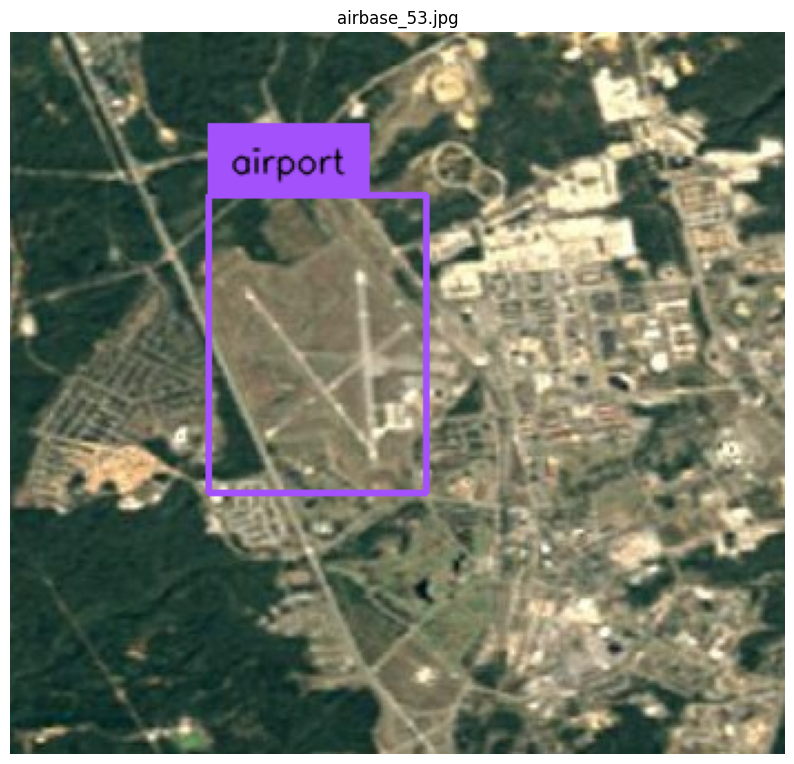

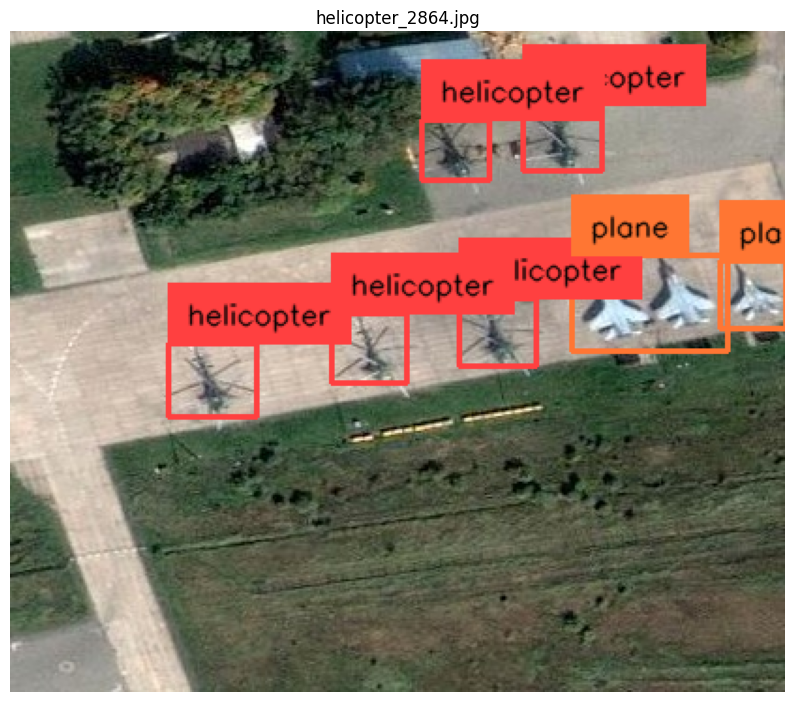

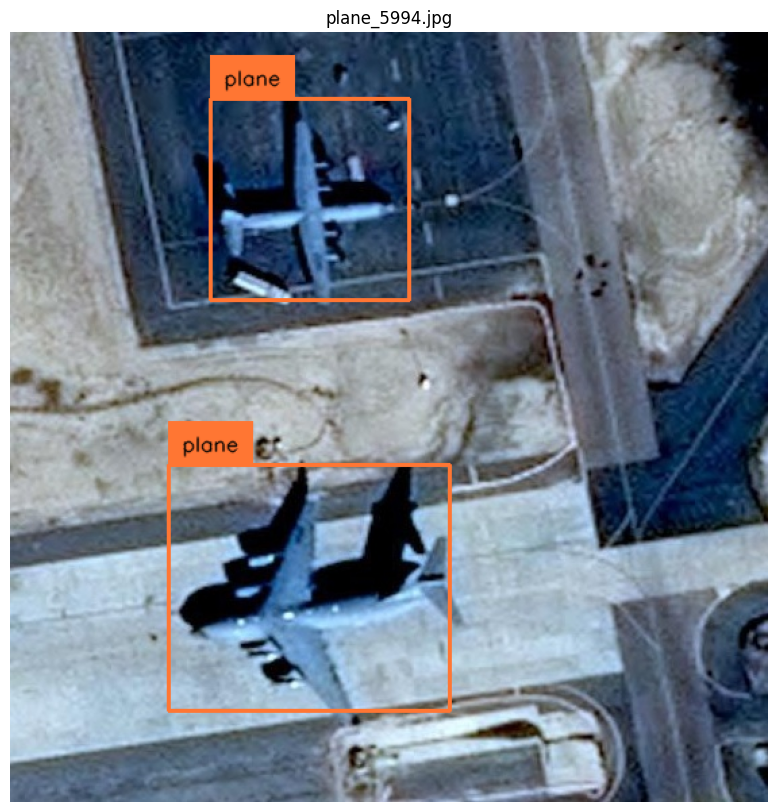

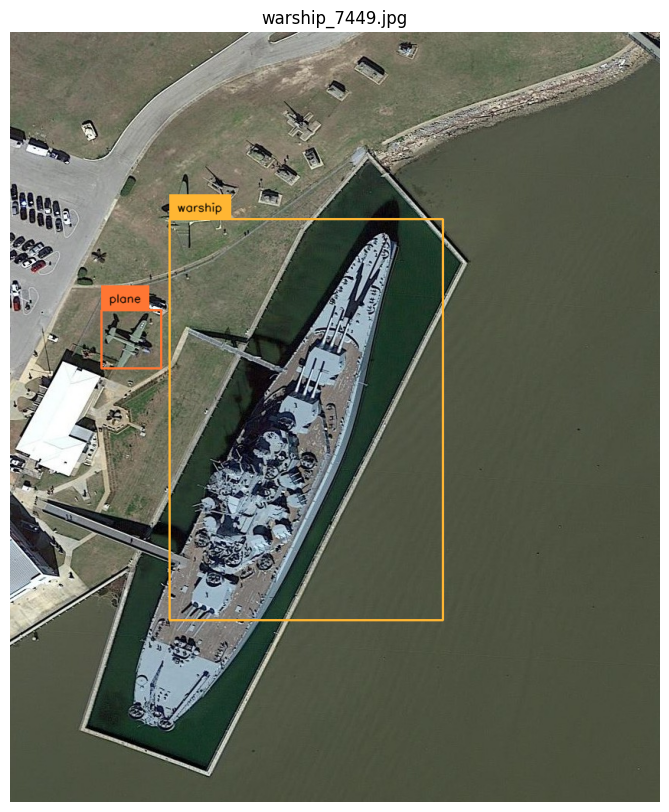

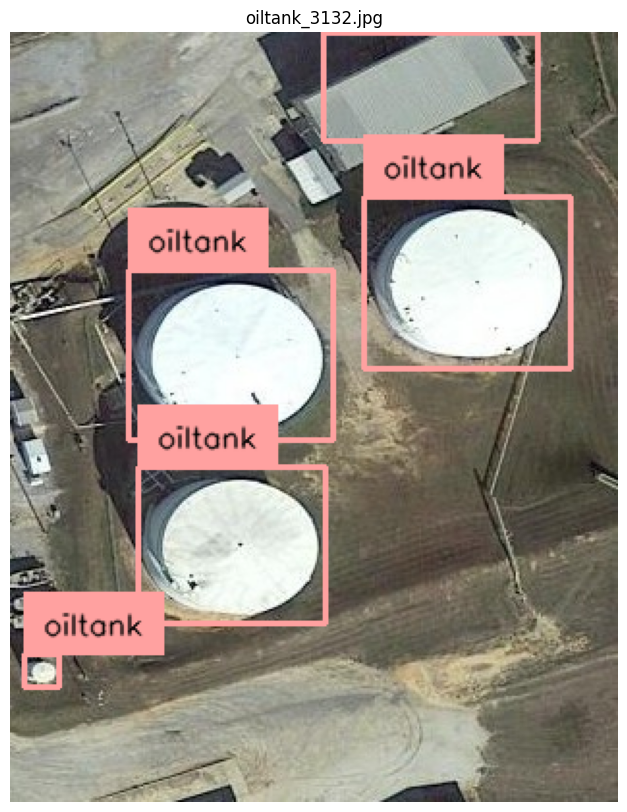

In [69]:
import cv2
import supervision as sv
import matplotlib.pyplot as plt
import os

image_paths = sv.list_files_with_extensions(
    directory="/content/test/",
    extensions=['png', 'jpg', 'jpeg']
)

label_annotator = sv.LabelAnnotator(text_color=sv.Color.BLACK)
bounding_box_annotator = sv.BoundingBoxAnnotator()

for image_path in image_paths:
    image = cv2.imread(image_path)

    result = model.infer(image, confidence=0.1)[0]
    detections = sv.Detections.from_inference(result)

    annotated_image = image.copy()
    annotated_image = bounding_box_annotator.annotate(scene=annotated_image, detections=detections)
    annotated_image = label_annotator.annotate(scene=annotated_image, detections=detections)

    annotated_image_rgb = cv2.cvtColor(annotated_image, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(10, 10))
    plt.imshow(annotated_image_rgb)
    plt.axis('off')
    plt.title(os.path.basename(image_path))
    plt.show()
